###  Connecting to Neo4j

In [1]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j+s://8c7b06ba.databases.neo4j.io"
USERNAME = "8c7b06ba"
PASSWORD = "qD0ehEZuPfSVjJ5F6oNsxIrF297R3ckAEmIM0DZ296Y"

driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))



### Helper to run queries

In [2]:
def run_query(query, params=None):
    with driver.session() as session:
        result = session.run(query, params or {})
        return [record.data() for record in result]

def run_df(query, params=None):
    return pd.DataFrame(run_query(query, params))

### Loading data files

In [3]:
base_path = "/Users/kalafejzo/mids205_project3_kala/data"

users = pd.read_csv(f"{base_path}/users.csv")
friend_edges = pd.read_csv(f"{base_path}/friend_edges.csv")
posts = pd.read_csv(f"{base_path}/posts.csv")
likes = pd.read_csv(f"{base_path}/likes.csv")
circles = pd.read_csv(f"{base_path}/all_circles.csv")

### Loading users

In [4]:
def load_users(tx, rows):
    query = """
    UNWIND $rows AS row
    MERGE (u:User {user_id: toInteger(row.user_id)})
    SET u.is_ego = CASE
      WHEN row.is_ego IN [True, 'True', 'true', 1, '1'] THEN true
      ELSE false
    END,
    u.degree = toInteger(row.degree),
    u.circle_count = toInteger(row.circle_count),
    u.ego_network_count = toInteger(row.ego_network_count),
    u.primary_ego_id = CASE
      WHEN row.primary_ego_id IS NULL OR row.primary_ego_id = '' THEN NULL
      ELSE toInteger(row.primary_ego_id)
    END
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_users, users.to_dict("records"))

### Loading Friendships


In [5]:
def load_friend_edges(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u1:User {user_id: toInteger(row.source)})
    MATCH (u2:User {user_id: toInteger(row.target)})
    MERGE (u1)-[:FRIENDS_WITH]->(u2)
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_friend_edges, friend_edges.to_dict("records"))

### Loading Posts

In [6]:
def load_posts(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u:User {user_id: toInteger(row.user_id)})
    MERGE (p:Post {post_id: row.post_id})
    SET p.topic_circle = row.topic_circle,
        p.engagement_seed = toFloat(row.engagement_seed)
    MERGE (u)-[:POSTED]->(p)
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_posts, posts.to_dict("records"))

### Loading Likes

In [7]:
def load_likes(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u:User {user_id: toInteger(row.user_id)})
    MATCH (p:Post {post_id: row.post_id})
    MERGE (u)-[:LIKED]->(p)
    """
    tx.run(query, rows=rows)

with driver.session() as session:
    session.execute_write(load_likes, likes.to_dict("records"))

### Loading circles

In [8]:
def load_circles(tx, rows):
    query = """
    UNWIND $rows AS row
    MERGE (c:Circle {circle_key: toString(row.ego_id) + '_' + row.circle_name})
    SET c.ego_id = toInteger(row.ego_id),
        c.circle_name = row.circle_name
    """
    tx.run(query, rows=rows)

def load_circle_memberships(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (u:User {user_id: toInteger(row.member_id)})
    MATCH (c:Circle {circle_key: toString(row.ego_id) + '_' + row.circle_name})
    MERGE (u)-[:MEMBER_OF]->(c)
    """
    tx.run(query, rows=rows)

### Loads in batches

In [9]:
def batch_records(df, batch_size=1000):
    for start in range(0, len(df), batch_size):
        yield df.iloc[start:start+batch_size].to_dict("records")

with driver.session() as session:
    for batch in batch_records(circles, 1000):
        session.execute_write(load_circles, batch)

with driver.session() as session:
    for batch in batch_records(circles, 1000):
        session.execute_write(load_circle_memberships, batch)

### Run Degree Centrality Algorithm
Finds the most highly connected users in the network, allowing us to identify influential nodes that may play a key role in information dissemination and engagement.

<Axes: xlabel='user_id'>

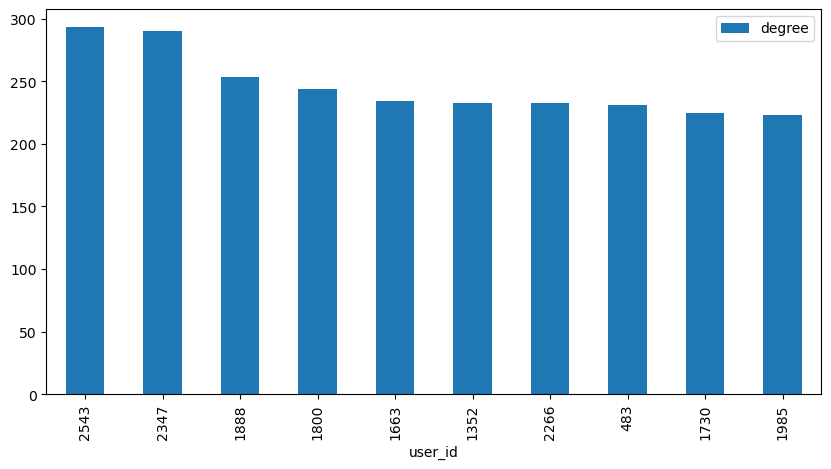

In [10]:
degree_df = run_df("""
MATCH (u:User)-[:FRIENDS_WITH]-()
RETURN u.user_id AS user_id,
       count(*) AS degree
ORDER BY degree DESC
LIMIT 10
""")

degree_df
degree_df.plot.bar(x='user_id', y='degree', figsize=(10,5))

### Run Shortest Path Algorithm
Finds the shortest connection between two users in the network by following friendship links. This helps us measure social distance and understand how closely two users are connected within the graph.

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
G = nx.Graph()
G.add_nodes_from(users["user_id"].tolist())
G.add_edges_from(friend_edges[["source", "target"]].itertuples(index=False, name=None))

ego_users = users.loc[users["is_ego"] == 1, "user_id"].tolist()

results = []

for ego in ego_users:
    lengths = nx.single_source_shortest_path_length(G, ego)
    dists = [d for node, d in lengths.items() if node != ego]

    results.append({
        "ego_user": ego,
        "reachable_users": len(dists),
        "avg_shortest_path": sum(dists) / len(dists) if len(dists) > 0 else None,
        "max_shortest_path": max(dists) if len(dists) > 0 else None
    })

results_df = pd.DataFrame(results).sort_values("avg_shortest_path", na_position="last")
results_df

,ego_user,reachable_users,avg_shortest_path,max_shortest_path
1,107,3926,3.848956,9.0
2,348,3926,4.157667,10.0
6,1684,3926,4.225166,9.0
3,414,3926,4.397860,10.0
0,0,3926,4.928935,9.0
5,698,3926,5.577178,12.0
4,686,0,NaN,NaN
7,1912,0,NaN,NaN
8,3437,0,NaN,NaN
9,3980,0,NaN,NaN


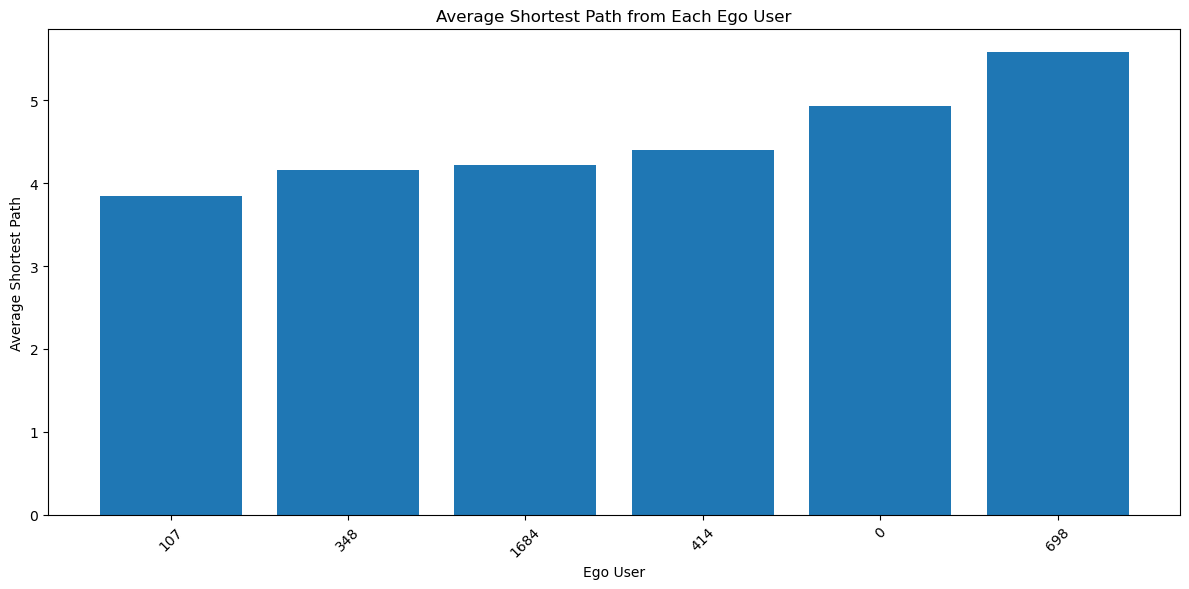

In [13]:
plt.figure(figsize=(12, 6))
plt.bar(results_df["ego_user"].astype(str), results_df["avg_shortest_path"])
plt.xlabel("Ego User")
plt.ylabel("Average Shortest Path")
plt.title("Average Shortest Path from Each Ego User")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

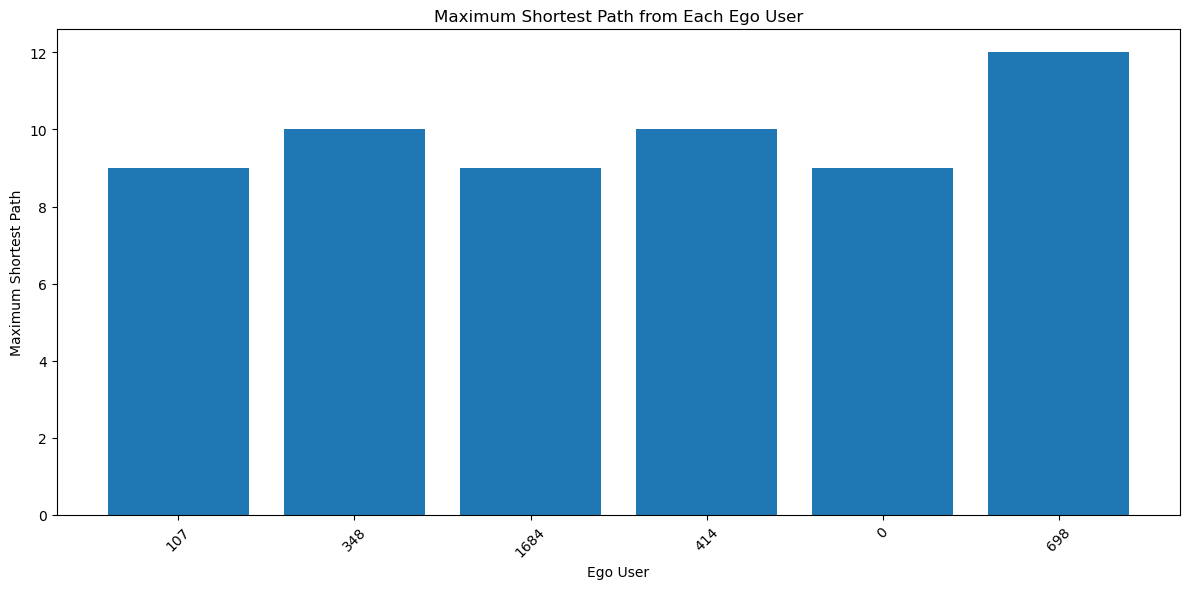

In [14]:
plt.figure(figsize=(12, 6))
plt.bar(results_df["ego_user"].astype(str), results_df["max_shortest_path"])
plt.xlabel("Ego User")
plt.ylabel("Maximum Shortest Path")
plt.title("Maximum Shortest Path from Each Ego User")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Run Betweenness Centrality
All pairs shortest path, for each node how many paths pass through the node; high betweenness - control point, bridge, high influence over flow within graph; pivotal node - lies on every path between two other nodes

## GDS Plugin not available using alternative networkx

In [15]:
import networkx as nx

In [16]:
G = nx.Graph()
G.add_nodes_from(users["user_id"].tolist())
G.add_edges_from(friend_edges[["source", "target"]].itertuples(index=False, name=None))

General Network Info

In [22]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 4039
Number of edges: 84243


In [19]:
betweenness = nx.betweenness_centrality(G)

betweenness_df = pd.DataFrame(
    [{"user_id": node, "betweenness": score} for node, score in betweenness.items()]
)

betweenness_df = betweenness_df.merge(
    users[["user_id", "is_ego"]],
    on="user_id",
    how="left"
).sort_values("betweenness", ascending=False).head(10)

betweenness_df

,user_id,betweenness,is_ego
1085,1085,0.239393,0
1718,1718,0.162087,0
698,698,0.086914,1
1577,1577,0.086833,0
862,862,0.084959,0
1405,1405,0.082429,0
1165,1165,0.077259,0
136,136,0.069862,0
107,107,0.066364,1
171,171,0.063492,0


In [20]:
print(G.degree(1085))

64


In [21]:
print(G.degree(171))

22
